In [1]:
import sys
import os
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Import modul internal proyek Anda
sys.path.append(os.path.abspath(os.path.join('..')))
from src.data_loader import load_stock_data, dataset_splitting
from src.visualizer import plot_daily_candlestick, plot_interactive_candlestick
from src.features import create_features          # Sesuaikan nama fungsi jika berbeda
from src.label import create_labels                # Sesuaikan nama fungsi jika berbeda
from src.model_config import MODEL_CONFIGS         # Kamus konfigurasi model & grid
from src.modelling import TargetModellingPipeline  # Pipeline retraining per target
from src.risk_manager import evaluate_trade_risk   # Otak manajemen risiko kuantitatif
from src.backtest import WalkForwardBacktester

print("✓ Seluruh modul berhasil diimpor.")

✓ Seluruh modul berhasil diimpor.


In [2]:
# 1. Unduh Data Historis Saham
ticker_target = "BUMI.JK"
start_date = "2014-11-01"
end_date = "2025-06-30"
end_date_today = datetime.now().strftime('%Y-%m-%d')

df_bumi = load_stock_data(ticker=ticker_target, start_date=start_date, end_date=end_date_today)

Mengunduh data terbaru untuk BUMI.JK dari Yahoo Finance...
Berhasil memuat 2899 baris data untuk BUMI.JK.
Info Data Cleaning: Menghapus 123 baris data (NaN atau Volume 0).
Berhasil memuat 2776 baris data bersih untuk BUMI.JK.


In [3]:

plot_interactive_candlestick(df=df_bumi, ticker_name="BUMI", start_date="2024-01-01", end_date="2024-12-31")

In [4]:
# 2. Replikasi Rekayasa Fitur (X) & Target Label (y)
df_features = create_features(df_bumi.copy()) # Panggil fungsi dari features.py
df_labels = create_labels(df_bumi.copy())     # Panggil fungsi dari label.py

# Ekstrak daftar kolom fitur (mengabaikan kolom NaN)
feature_cols = [col for col in df_features.columns if col not in ['Open', 'High', 'Low', 'Close', 'Volume']]

# 3. Pisahkan Data ke Fase In-Sample & Out-of-Sample menggunakan dataset_splitting
X_in, y_in_raw, X_oos, y_oos_raw, _, _ = dataset_splitting(df_features, df_labels)

# Bungkus dictionary target label untuk memfasilitasi 5 model
y_in_dict = {target: y_in_raw[target] for target in ['trend_slope', 'return', 'risk', 'days_to_max', 'days_to_min']}
y_oos_dict = {target: y_oos_raw[target] for target in ['trend_slope', 'return', 'risk', 'days_to_max', 'days_to_min']}

# 4. Inisialisasi & Jalankan Backtest
backtester = WalkForwardBacktester(
    ticker=ticker_target,
    initial_capital=5_000_000.0,
    max_risk_pct=0.03,
    max_alloc_pct=0.50,
    fee_buy=0.0015,
    fee_sell=0.0025,
    min_rr_ratio=1.0
)

# Jalankan simulasi pada data Out-of-Sample (2024 - 2025)
df_trades_result, df_equity_curve = backtester.run_backtest(
    X_in=X_in,
    y_in_dict=y_in_dict,
    X_oos=X_oos,
    y_oos_dict=y_oos_dict,
    df_raw_prices=df_bumi,
    feature_cols=feature_cols
)

 MEMULAI SIMULASI WALK-FORWARD ANALYSIS (BUMI.JK)
 Modal Awal: Rp5,000,000.00

[INIT] Memuat model awal dari folder models/bumi...
--------------------------------------------------
PERIODE KELOLAAN: 2024-01 | Ukuran Data OOS: 22 Hari Bursa
--------------------------------------------------
[RETRAIN] Bulan pertama Out-of-Sample: menggunakan model awal tanpa retrain.
  [BUY LOG]  2024-01-04 | Beli                 @ Rp99.00   | Lot: 235  | Modal : Rp2,329,989.75            | Ekuitas: Rp5,000,000.00
  [SELL LOG] 2024-01-08 | Jual (Time-Stop   ) @ Rp97.00   | Lot: 235  | Profit: Rp-56,188.50 ( -2.41%) | Ekuitas: Rp4,943,811.50
--------------------------------------------------
PERIODE KELOLAAN: 2024-02 | Ukuran Data OOS: 18 Hari Bursa
--------------------------------------------------

[RETRAIN] Melatih ulang 5 model dengan data Expanding Window (2141 baris)...
[RETRAIN] Seluruh 5 model berhasil diperbarui.

--------------------------------------------------
PERIODE KELOLAAN: 2024-03 | Uku

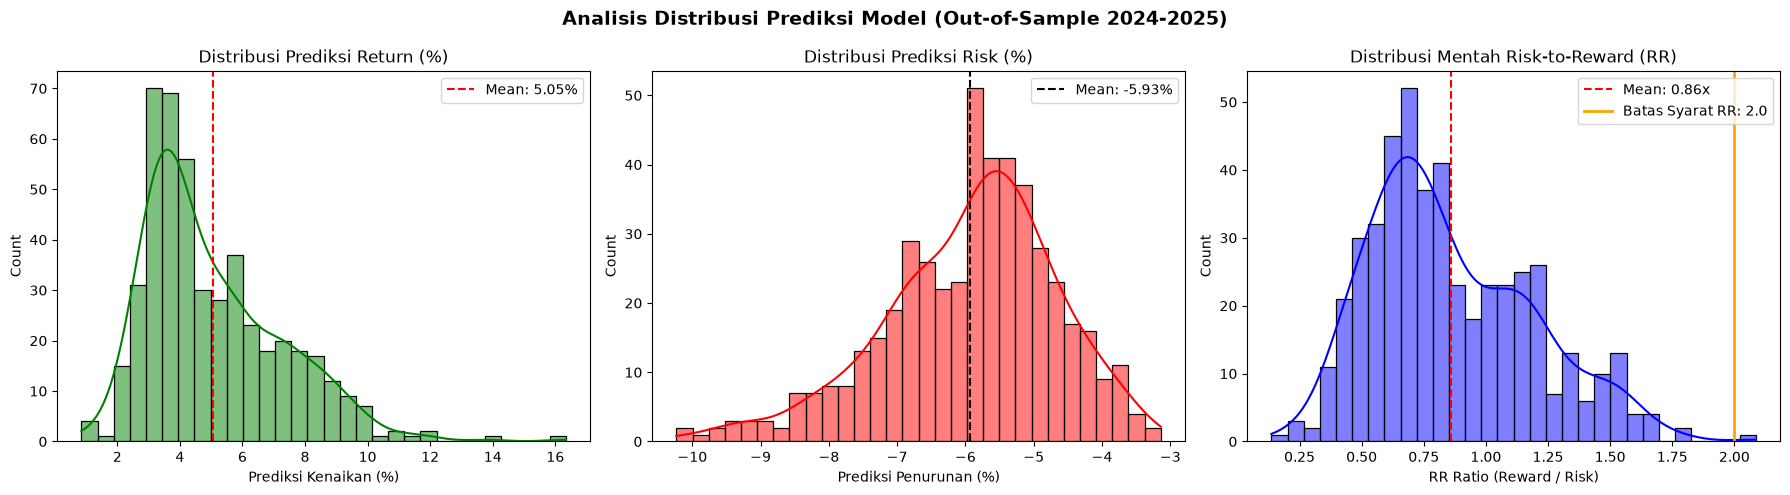

=== STATISTIK PREDIKSI MODEL ===
                     mean       std        min       50%        max
pred_return_pct  5.047939  2.189913   0.852075  4.337470  16.333794
pred_risk_pct   -5.931045  1.269068 -10.233021 -5.768893  -3.138838
raw_rr_ratio     0.858480  0.328712   0.136616  0.787945   2.086162


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Ekstrak model awal dari objek backtester yang sudah diinisialisasi
model_return = backtester.trained_pipelines['return']
features_return = backtester.features_used['return']

model_risk = backtester.trained_pipelines['risk']
features_risk = backtester.features_used['risk']

# 2. Lakukan prediksi massal pada seluruh data Out-of-Sample (X_oos)
# Drop baris NaN agar dimensi sesuai saat di-predict
X_oos_clean_ret = X_oos.dropna(subset=features_return)
X_oos_clean_risk = X_oos.dropna(subset=features_risk)

# Menyamakan index agar bisa digabung (ambil irisan index yang valid)
valid_idx = X_oos_clean_ret.index.intersection(X_oos_clean_risk.index)

pred_returns = model_return.predict(X_oos.loc[valid_idx, features_return])
pred_risks = model_risk.predict(X_oos.loc[valid_idx, features_risk])

# 3. Buat DataFrame khusus untuk analisis distribusi
df_dist = pd.DataFrame({
    'pred_return_pct': pred_returns * 100, # Jadikan persentase
    'pred_risk_pct': pred_risks * 100      # Jadikan persentase
}, index=valid_idx)

# Asumsi risiko tidak boleh 0 agar tidak error saat pembagian
df_dist['pred_risk_pct'] = df_dist['pred_risk_pct'].replace(0, -0.01)

# Hitung Rasio Risk-to-Reward Mentah (Tanpa Fee)
# Karena risk bernilai negatif, kita gunakan abs()
df_dist['raw_rr_ratio'] = df_dist['pred_return_pct'] / df_dist['pred_risk_pct'].abs()

# 4. Visualisasi Distribusi
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plt.suptitle("Analisis Distribusi Prediksi Model (Out-of-Sample 2024-2025)", fontsize=14, fontweight='bold')

# Plot 1: Distribusi Prediksi Return
sns.histplot(df_dist['pred_return_pct'], bins=30, kde=True, ax=axes[0], color='green')
axes[0].set_title('Distribusi Prediksi Return (%)')
axes[0].set_xlabel('Prediksi Kenaikan (%)')
axes[0].axvline(df_dist['pred_return_pct'].mean(), color='red', linestyle='--', label=f"Mean: {df_dist['pred_return_pct'].mean():.2f}%")
axes[0].legend()

# Plot 2: Distribusi Prediksi Risk
sns.histplot(df_dist['pred_risk_pct'], bins=30, kde=True, ax=axes[1], color='red')
axes[1].set_title('Distribusi Prediksi Risk (%)')
axes[1].set_xlabel('Prediksi Penurunan (%)')
axes[1].axvline(df_dist['pred_risk_pct'].mean(), color='black', linestyle='--', label=f"Mean: {df_dist['pred_risk_pct'].mean():.2f}%")
axes[1].legend()

# Plot 3: Distribusi Risk-to-Reward Ratio (RR)
# Batasi nilai maksimum x agar grafik tidak rusak karena outlier pembagian tak terhingga
sns.histplot(df_dist['raw_rr_ratio'][df_dist['raw_rr_ratio'] < 10], bins=30, kde=True, ax=axes[2], color='blue')
axes[2].set_title('Distribusi Mentah Risk-to-Reward (RR)')
axes[2].set_xlabel('RR Ratio (Reward / Risk)')
axes[2].axvline(df_dist['raw_rr_ratio'].mean(), color='red', linestyle='--', label=f"Mean: {df_dist['raw_rr_ratio'].mean():.2f}x")
axes[2].axvline(2.0, color='orange', linestyle='-', linewidth=2, label="Batas Syarat RR: 2.0")
axes[2].legend()

plt.tight_layout()
plt.show()

# 5. Tampilkan Statistik Deskriptif
print("=== STATISTIK PREDIKSI MODEL ===")
print(df_dist.describe().T[['mean', 'std', 'min', '50%', 'max']])

In [8]:
# Menampilkan grafik interaktif yang berisi Candlestick, Volume, dan Hasil Prediksi
plot_interactive_candlestick(
    df=df_bumi,               # Dataframe OHLCV saham (sesuaikan nama variabel jika berbeda)
    ticker_name=ticker_target,
    start_date="2024-01-01",  # Opsional: sesuaikan rentang zoom awal jika diperlukan
    end_date="2025-12-31",
    predictions_df=backtester.predictions_df,  # Ambil data dari objek backtester
    equity_curve_df=df_equity_curve,           # Diambil dari output run_backtest()
    trades_df=df_trades_result                 # Diambil dari output run_backtest()
)


In [7]:
save_csv_path="../data/processed/jurnal_trading.csv"
df_journal = backtester.generate_journal(df_bumi, save_csv_path)

# Tampilkan jurnal
display(df_journal)


[INFO] Jurnal berhasil disimpan ke: ../data/processed/jurnal_trading.csv


,Open,High,Low,Close,Volume,Keputusan,Harga Eksekusi,Lot,Value Transaksi,Invested,Sisa Cash,Total Equity
Date,,,,,,,,,,,,
2024-01-02,85.00,97.00,85.00,95.00,"998,119,800",-,0.00,0,0.00,0.00,"5,000,000.00","5,000,000.00"
2024-01-03,94.00,103.00,94.00,98.00,"2,186,067,200",-,0.00,0,0.00,0.00,"5,000,000.00","5,000,000.00"
2024-01-04,99.00,101.00,97.00,99.00,"777,595,600",Buy,99.00,235,"2,329,989.75","2,326,500.00","2,670,010.25","4,996,510.25"
2024-01-05,99.00,102.00,98.00,99.00,"486,296,200",-,0.00,0,0.00,"2,326,500.00","2,670,010.25","4,996,510.25"
2024-01-08,100.00,100.00,95.00,97.00,"383,167,000",Sell,97.00,235,"2,273,801.25",0.00,"4,943,811.50","4,943,811.50"
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-22,348.00,394.00,346.00,394.00,"12,257,775,400",-,0.00,0,0.00,0.00,"5,304,212.40","5,304,212.40"
2025-12-23,402.00,406.00,376.00,380.00,"8,335,353,200",-,0.00,0,0.00,0.00,"5,304,212.40","5,304,212.40"
2025-12-24,382.00,384.00,360.00,362.00,"4,795,205,000",-,0.00,0,0.00,0.00,"5,304,212.40","5,304,212.40"


In [10]:
display(df_journal.head(20))

,Open,High,Low,Close,Volume,Keputusan,Harga Eksekusi,Lot,Value Transaksi,Invested,Sisa Cash,Total Equity
Date,,,,,,,,,,,,
2024-01-02,85.00,97.00,85.00,95.00,"998,119,800",-,0.00,0,0.00,0.00,"5,000,000.00","5,000,000.00"
2024-01-03,94.00,103.00,94.00,98.00,"2,186,067,200",-,0.00,0,0.00,0.00,"5,000,000.00","5,000,000.00"
2024-01-04,99.00,101.00,97.00,99.00,"777,595,600",Buy,99.00,235,"2,329,989.75","2,326,500.00","2,670,010.25","4,996,510.25"
2024-01-05,99.00,102.00,98.00,99.00,"486,296,200",-,0.00,0,0.00,"2,326,500.00","2,670,010.25","4,996,510.25"
2024-01-08,100.00,100.00,95.00,97.00,"383,167,000",Sell,97.00,235,"2,273,801.25",0.00,"4,943,811.50","4,943,811.50"
2024-01-09,97.00,98.00,93.00,96.00,"487,131,500",-,0.00,0,0.00,0.00,"4,943,811.50","4,943,811.50"
2024-01-10,97.00,100.00,95.00,96.00,"756,886,300",-,0.00,0,0.00,0.00,"4,943,811.50","4,943,811.50"
2024-01-11,96.00,97.00,91.00,91.00,"607,661,400",-,0.00,0,0.00,0.00,"4,943,811.50","4,943,811.50"
2024-01-12,91.00,94.00,91.00,93.00,"236,972,000",-,0.00,0,0.00,0.00,"4,943,811.50","4,943,811.50"
